# 1.2. Thống kê mô tả

Phân tích thống kê mô tả cho tập dữ liệu **Wine Quality Red**:
- Các chỉ số: mean, median, std, min, max, quartiles...
- Biểu đồ phân phối
- Ma trận tương quan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

DATA_PATH = Path("dataset/winequality-red.csv")
df = pd.read_csv(DATA_PATH)

## Thống kê mô tả (Mean, Median, Std, ...)

In [11]:
thong_ke = df.describe().T
thong_ke = thong_ke.rename(columns={
    "count": "Số lượng",
    "mean": "Mean (Trung bình)",
    "std": "Std (Độ lệch chuẩn)",
    "min": "Giá trị nhỏ nhất",
    "25%": "Q1 (25%)",
    "50%": "Median (Trung vị)",
    "75%": "Q3 (75%)",
    "max": "Giá trị lớn nhất",
})

display(thong_ke.round(4))

,Số lượng,Mean (Trung bình),Std (Độ lệch chuẩn),Giá trị nhỏ nhất,Q1 (25%),Median (Trung vị),Q3 (75%),Giá trị lớn nhất
fixed acidity,1599.0,8.3196,1.7411,4.6000,7.1000,7.9000,9.2000,15.9000
volatile acidity,1599.0,0.5278,0.1791,0.1200,0.3900,0.5200,0.6400,1.5800
citric acid,1599.0,0.2710,0.1948,0.0000,0.0900,0.2600,0.4200,1.0000
residual sugar,1599.0,2.5388,1.4099,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1599.0,0.0875,0.0471,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1599.0,15.8749,10.4602,1.0000,7.0000,14.0000,21.0000,72.0000
total sulfur dioxide,1599.0,46.4678,32.8953,6.0000,22.0000,38.0000,62.0000,289.0000
density,1599.0,0.9967,0.0019,0.9901,0.9956,0.9968,0.9978,1.0037
pH,1599.0,3.3111,0.1544,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,1599.0,0.6581,0.1695,0.3300,0.5500,0.6200,0.7300,2.0000


In [3]:
# Bổ sung thêm các chỉ số: phương sai, độ lệch, khoảng biến thiên
bo_sung = pd.DataFrame({
    "Phương sai (Variance)": df.var(),
    "Độ lệch (Skewness)": df.skew(),
    "Độ nhọn (Kurtosis)": df.kurtosis(),
    "Khoảng biến thiên (Range)": df.max() - df.min(),
})

display(bo_sung.round(4))

,Phương sai (Variance),Độ lệch (Skewness),Độ nhọn (Kurtosis),Khoảng biến thiên (Range)
fixed acidity,3.0314,0.9828,1.1321,11.3000
volatile acidity,0.0321,0.6716,1.2255,1.4600
citric acid,0.0379,0.3183,-0.7890,1.0000
residual sugar,1.9879,4.5407,28.6176,14.6000
chlorides,0.0022,5.6803,41.7158,0.5990
free sulfur dioxide,109.4149,1.2506,2.0236,71.0000
total sulfur dioxide,1082.1024,1.5155,3.8098,283.0000
density,0.0000,0.0713,0.9341,0.0136
pH,0.0238,0.1937,0.8069,1.2700
sulphates,0.0287,2.4287,11.7203,1.6700


## Biểu đồ phân phối

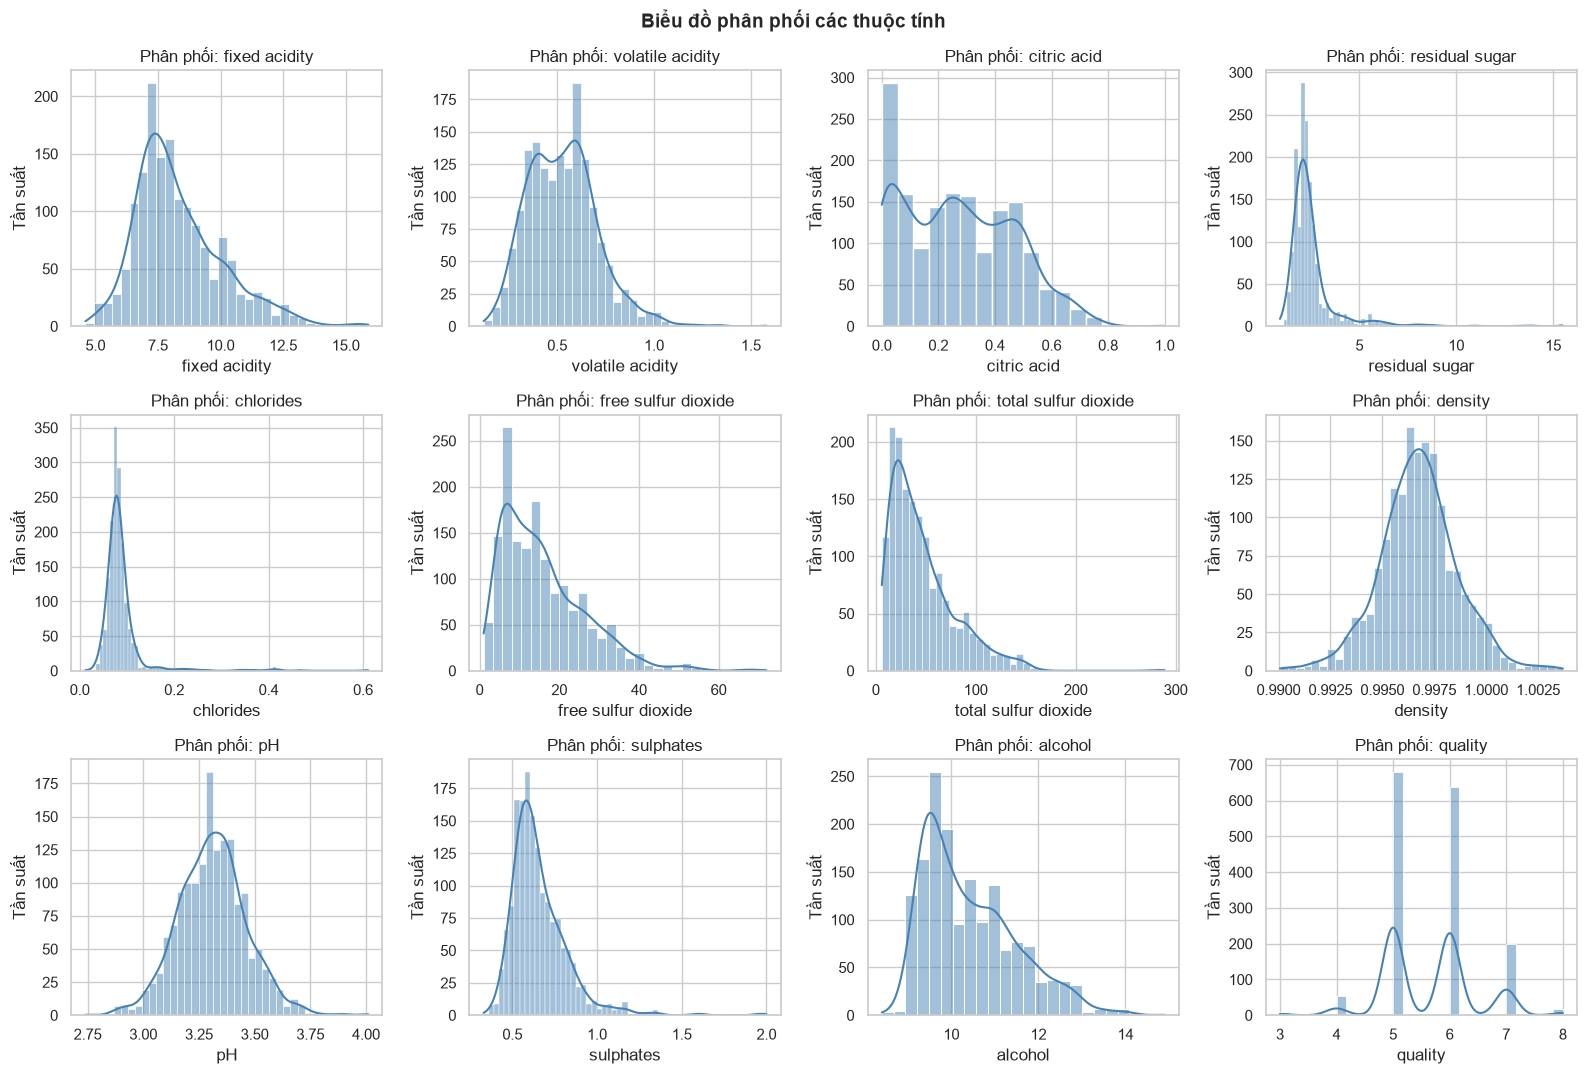

In [4]:
columns = df.columns
n_cols = 4
n_rows = int(np.ceil(len(columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(f"Phân phối: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")

for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle("Biểu đồ phân phối các thuộc tính", y=1.02, fontsize=14, fontweight="bold")
plt.show()

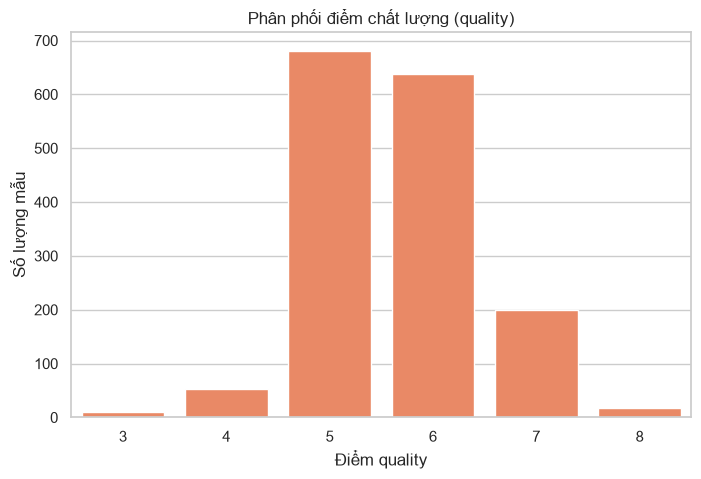

In [5]:
# Phân phối biến mục tiêu quality (dạng cột)
plt.figure(figsize=(8, 5))
quality_counts = df["quality"].value_counts().sort_index()
sns.barplot(x=quality_counts.index, y=quality_counts.values, color="coral", edgecolor="white")
plt.title("Phân phối điểm chất lượng (quality)")
plt.xlabel("Điểm quality")
plt.ylabel("Số lượng mẫu")
plt.show()

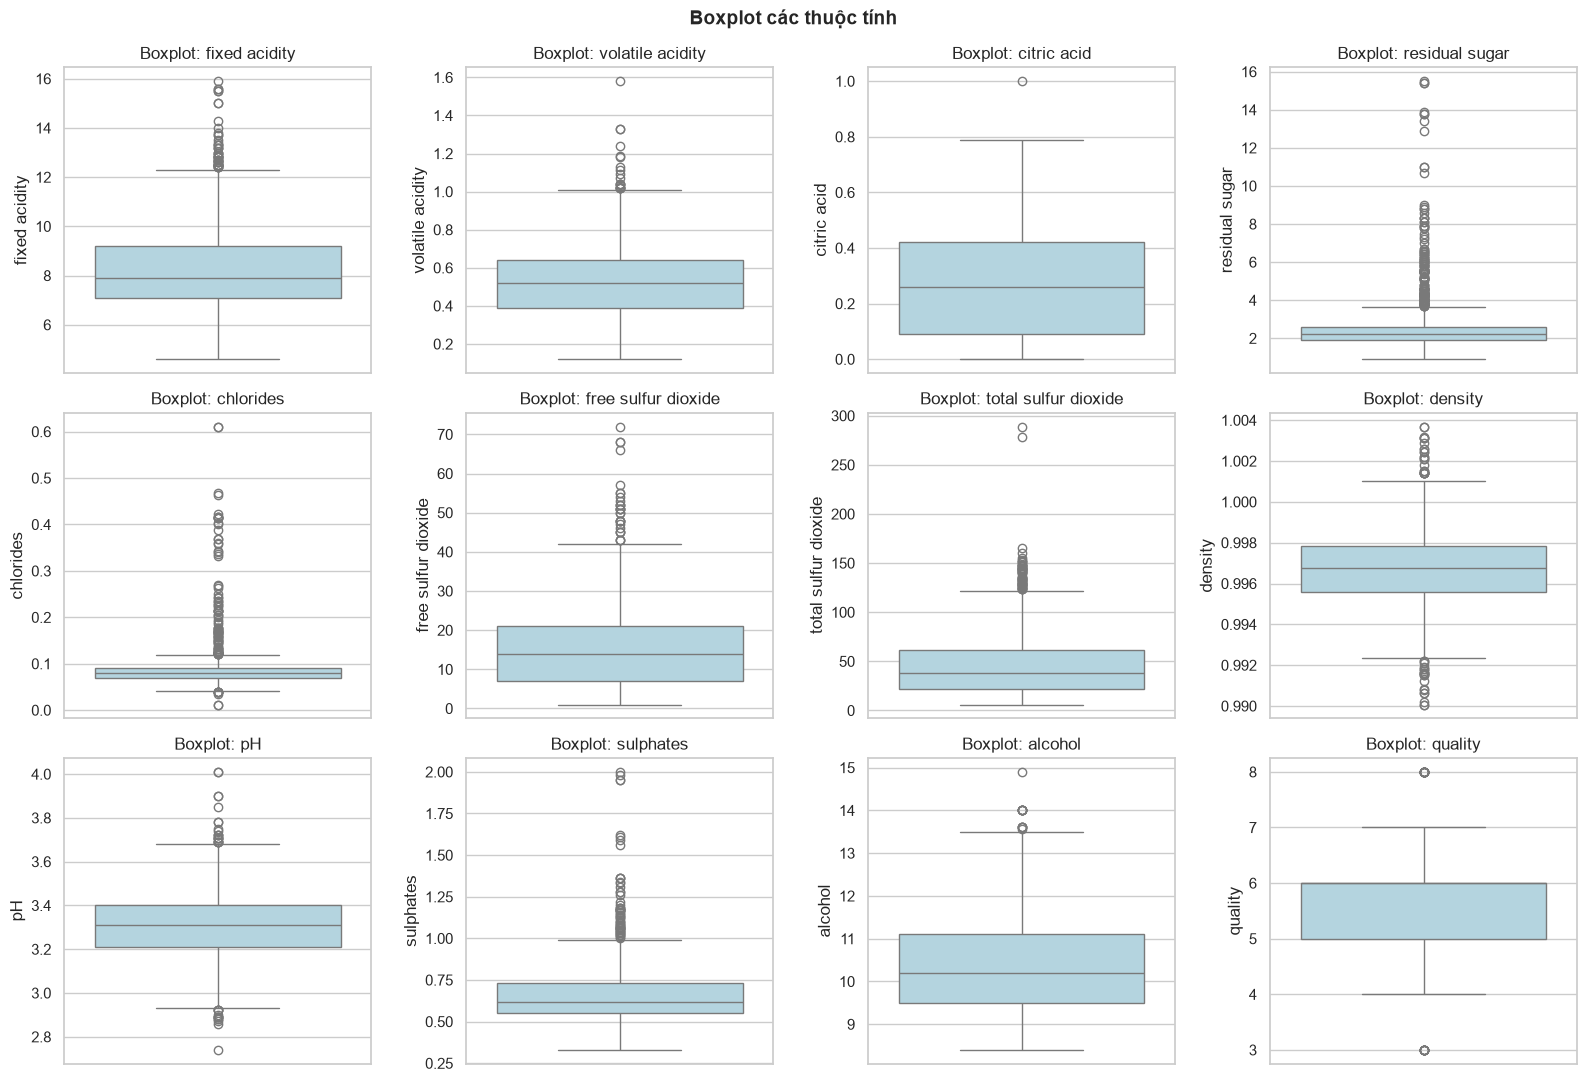

In [6]:
# Boxplot để quan sát phân phối và giá trị ngoại lai
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_ylabel(col)

for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle("Boxplot các thuộc tính", y=1.02, fontsize=14, fontweight="bold")
plt.show()

## Ma trận tương quan

In [7]:
corr_matrix = df.corr()

display(corr_matrix.round(4))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.0000,-0.2561,0.6717,0.1148,0.0937,-0.1538,-0.1132,0.6680,-0.6830,0.1830,-0.0617,0.1241
volatile acidity,-0.2561,1.0000,-0.5525,0.0019,0.0613,-0.0105,0.0765,0.0220,0.2349,-0.2610,-0.2023,-0.3906
citric acid,0.6717,-0.5525,1.0000,0.1436,0.2038,-0.0610,0.0355,0.3649,-0.5419,0.3128,0.1099,0.2264
residual sugar,0.1148,0.0019,0.1436,1.0000,0.0556,0.1870,0.2030,0.3553,-0.0857,0.0055,0.0421,0.0137
chlorides,0.0937,0.0613,0.2038,0.0556,1.0000,0.0056,0.0474,0.2006,-0.2650,0.3713,-0.2211,-0.1289
free sulfur dioxide,-0.1538,-0.0105,-0.0610,0.1870,0.0056,1.0000,0.6677,-0.0219,0.0704,0.0517,-0.0694,-0.0507
total sulfur dioxide,-0.1132,0.0765,0.0355,0.2030,0.0474,0.6677,1.0000,0.0713,-0.0665,0.0429,-0.2057,-0.1851
density,0.6680,0.0220,0.3649,0.3553,0.2006,-0.0219,0.0713,1.0000,-0.3417,0.1485,-0.4962,-0.1749
pH,-0.6830,0.2349,-0.5419,-0.0857,-0.2650,0.0704,-0.0665,-0.3417,1.0000,-0.1966,0.2056,-0.0577
sulphates,0.1830,-0.2610,0.3128,0.0055,0.3713,0.0517,0.0429,0.1485,-0.1966,1.0000,0.0936,0.2514


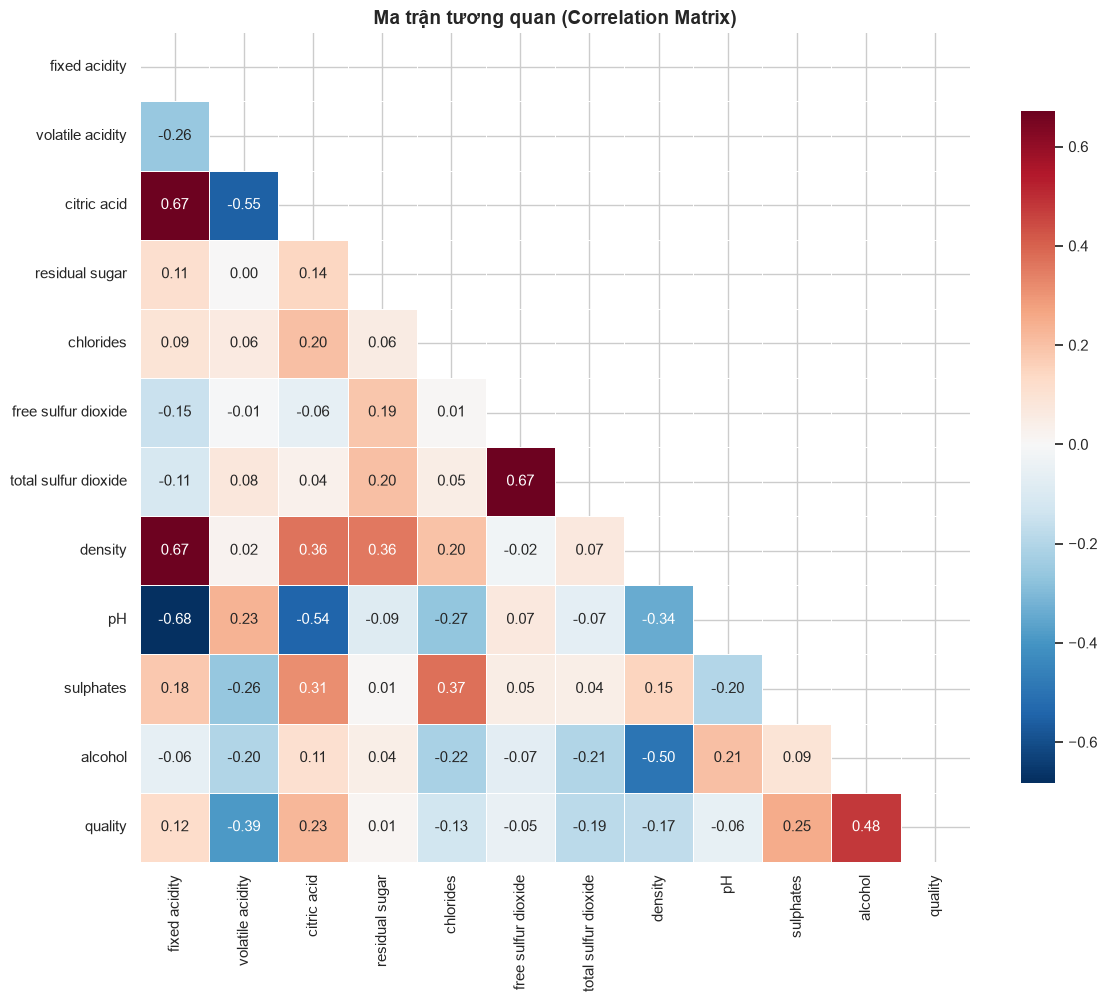

In [8]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Ma trận tương quan (Correlation Matrix)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\chum1\AppData\Local\Temp\ipykernel_10984\2235095645.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_quality.values, y=corr_quality.index, palette=colors)


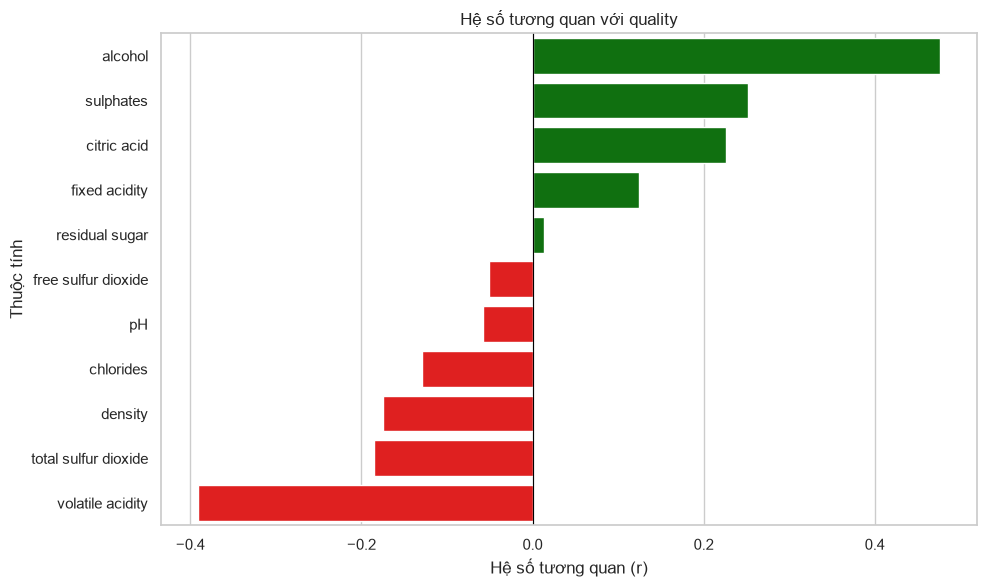


Tương quan với quality (sắp xếp giảm dần):
  • alcohol: 0.4762
  • sulphates: 0.2514
  • citric acid: 0.2264
  • fixed acidity: 0.1241
  • residual sugar: 0.0137
  • free sulfur dioxide: -0.0507
  • pH: -0.0577
  • chlorides: -0.1289
  • density: -0.1749
  • total sulfur dioxide: -0.1851
  • volatile acidity: -0.3906


In [9]:
# Tương quan với biến mục tiêu quality
corr_quality = corr_matrix["quality"].drop("quality").sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ["green" if v > 0 else "red" for v in corr_quality.values]
sns.barplot(x=corr_quality.values, y=corr_quality.index, palette=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Hệ số tương quan với quality")
plt.xlabel("Hệ số tương quan (r)")
plt.ylabel("Thuộc tính")
plt.tight_layout()
plt.show()

print("\nTương quan với quality (sắp xếp giảm dần):")
for col, val in corr_quality.items():
    print(f"  • {col}: {val:.4f}")

## Tóm tắt nhận xét

In [10]:
print("=" * 55)
print("TÓM TẮT THỐNG KÊ MÔ TẢ")
print("=" * 55)
print(f"\n• Số thuộc tính phân tích: {len(df.columns)}")
print(f"• Mean quality: {df['quality'].mean():.2f}")
print(f"• Median quality: {df['quality'].median():.2f}")
print(f"• Std quality: {df['quality'].std():.2f}")

top_pos = corr_quality.head(3)
top_neg = corr_quality.tail(3).sort_values()

print("\n• Tương quan dương mạnh nhất với quality:")
for col, val in top_pos.items():
    print(f"    - {col}: {val:.4f}")

print("\n• Tương quan âm mạnh nhất với quality:")
for col, val in top_neg.items():
    print(f"    - {col}: {val:.4f}")

TÓM TẮT THỐNG KÊ MÔ TẢ

• Số thuộc tính phân tích: 12
• Mean quality: 5.64
• Median quality: 6.00
• Std quality: 0.81

• Tương quan dương mạnh nhất với quality:
    - alcohol: 0.4762
    - sulphates: 0.2514
    - citric acid: 0.2264

• Tương quan âm mạnh nhất với quality:
    - volatile acidity: -0.3906
    - total sulfur dioxide: -0.1851
    - density: -0.1749
